## What is the most optimal skill to learn for Data Analysts?

Methodology

1. Group skills to determine the median salary and likelihood of being in posting.
2. Visualize median salary vs percent skill demand
3. (Optional) Determine if certain technologies are prevalant.

In [1]:
# importing libraries
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\rpran\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [31]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()
df_DA_US = df_DA_US[df_DA_US['salary_year_avg'].notna()]
total = int(len(df_DA_US))
df_DA_US_exp = df_DA_US.explode('job_skills')
df_DA_US_group = df_DA_US_exp.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False).head(10)
df_DA_US_group['percentage'] = df_DA_US_group['count'] / total * 100
df_DA_US_group

,count,median,percentage
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


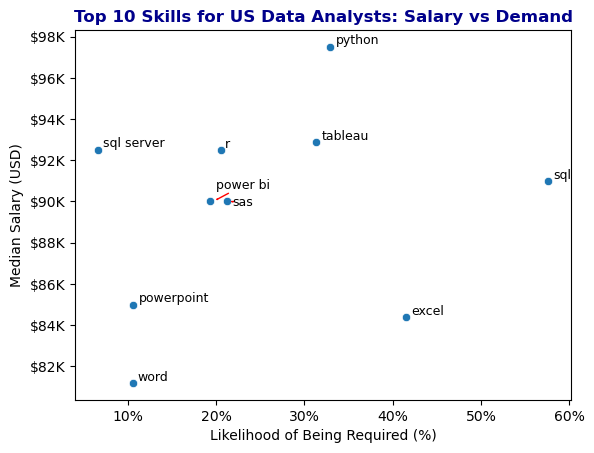

In [32]:
from adjustText import adjust_text
sns.scatterplot(data=df_DA_US_group, x='percentage', y='median')
texts = []
for i, txt in enumerate(df_DA_US_group.index):
    texts.append(plt.text(df_DA_US_group['percentage'].iloc[i]+0.4,df_DA_US_group['median'].iloc[i], txt, fontsize=9))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red'))
plt.title('Top 10 Skills for US Data Analysts: Salary vs Demand', fontsize=12, fontweight='bold', color='darkblue')
plt.xlabel('Likelihood of Being Required (%)')
plt.ylabel('Median Salary (USD)')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}%' if x >= 1 else f'{int(x*100)}%'))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'${int(y/1000)}K' if y >= 1000 else f'{int(y)}'))
plt.show() 

In [42]:
df_technology = df_DA_US['job_type_skills'].copy()
df_technology = df_technology.dropna()
df_technology = df_technology.drop_duplicates()

technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)
    for key, value in row_dict.items():
        if key in technology_dict:
            technology_dict[key] += value
        else: 
            technology_dict[key] = value

for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict.keys()

dict_keys(['analyst_tools', 'programming', 'cloud', 'os', 'webframeworks', 'other', 'databases', 'libraries', 'async', 'sync'])

In [45]:
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['Technology', 'Skills'])
df_technology = df_technology.explode('Skills')
df_technology

,Technology,Skills
0,analyst_tools,qlik
0,analyst_tools,ssis
0,analyst_tools,spreadsheet
0,analyst_tools,ssrs
0,analyst_tools,word
...,...,...
9,sync,zoom
9,sync,slack
9,sync,symphony
9,sync,microsoft teams


In [56]:
df_scatter = df_DA_US_group.merge(df_technology, left_on=df_DA_US_group.index, right_on='Skills')
df_scatter = df_scatter.drop_duplicates(subset='Skills')

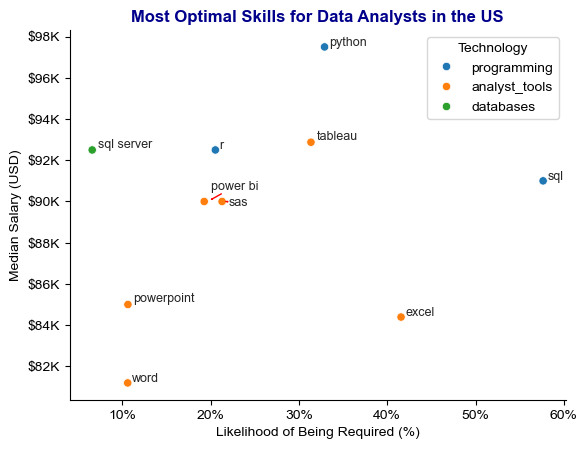

In [59]:
from adjustText import adjust_text
sns.scatterplot(
    data=df_scatter,
    x='percentage', 
    y='median',
    hue='Technology',
    )
sns.set_theme(style='ticks')
sns.despine()
texts = []
for i, txt in enumerate(df_scatter['Skills']):
    texts.append(plt.text(df_scatter['percentage'].iloc[i]+0.4,df_scatter['median'].iloc[i], txt, fontsize=9))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red'))
plt.title('Most Optimal Skills for Data Analysts in the US', fontsize=12, fontweight='bold', color='darkblue')
plt.xlabel('Likelihood of Being Required (%)')
plt.ylabel('Median Salary (USD)')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}%' if x >= 1 else f'{int(x*100)}%'))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'${int(y/1000)}K' if y >= 1000 else f'{int(y)}'))
plt.show() 